In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("cs-training.csv", index_col=0)

In [3]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape (rows, columns): (150000, 11)

Column names:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [6]:
df.isnull().sum()

,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


In [7]:
df["SeriousDlqin2yrs"].value_counts()

,count
SeriousDlqin2yrs,
0,139974
1,10026


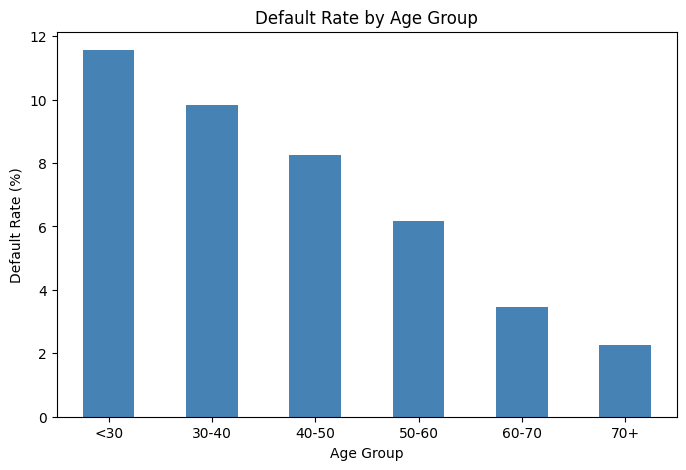

age_group
<30      11.56
30-40     9.82
40-50     8.26
50-60     6.17
60-70     3.47
70+       2.25
Name: SeriousDlqin2yrs, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Default rate by age group
df["age_group"] = pd.cut(df["age"], bins=[0, 30, 40, 50, 60, 70, 100],
                         labels=["<30", "30-40", "40-50", "50-60", "60-70", "70+"])

default_by_age = df.groupby("age_group", observed=True)["SeriousDlqin2yrs"].mean() * 100

plt.figure(figsize=(8, 5))
default_by_age.plot(kind="bar", color="steelblue")
plt.title("Default Rate by Age Group")
plt.ylabel("Default Rate (%)")
plt.xlabel("Age Group")
plt.xticks(rotation=0)
plt.show()

print(default_by_age.round(2))

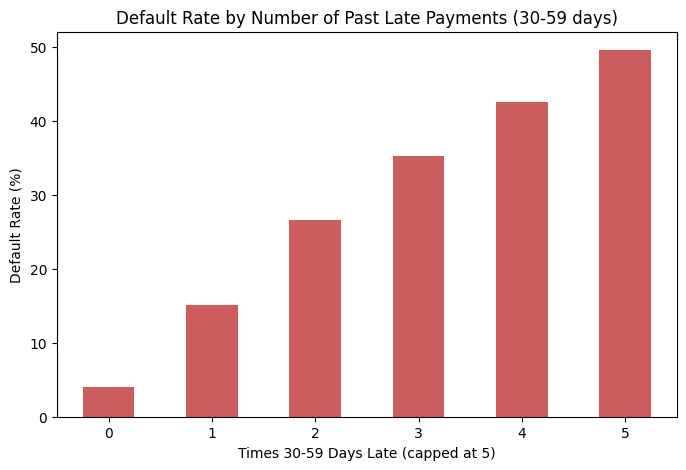

late_bucket
0     4.00
1    15.03
2    26.51
3    35.23
4    42.57
5    49.53
Name: SeriousDlqin2yrs, dtype: float64


In [9]:
# Default rate by number of times 30-59 days late
late_col = "NumberOfTime30-59DaysPastDueNotWorse"

# Group: people are bucketed by how many times they were late
df["late_bucket"] = df[late_col].clip(upper=5)  # cap at 5 so rare extreme values don't distort

default_by_late = df.groupby("late_bucket")["SeriousDlqin2yrs"].mean() * 100

plt.figure(figsize=(8, 5))
default_by_late.plot(kind="bar", color="indianred")
plt.title("Default Rate by Number of Past Late Payments (30-59 days)")
plt.ylabel("Default Rate (%)")
plt.xlabel("Times 30-59 Days Late (capped at 5)")
plt.xticks(rotation=0)
plt.show()

print(default_by_late.round(2))

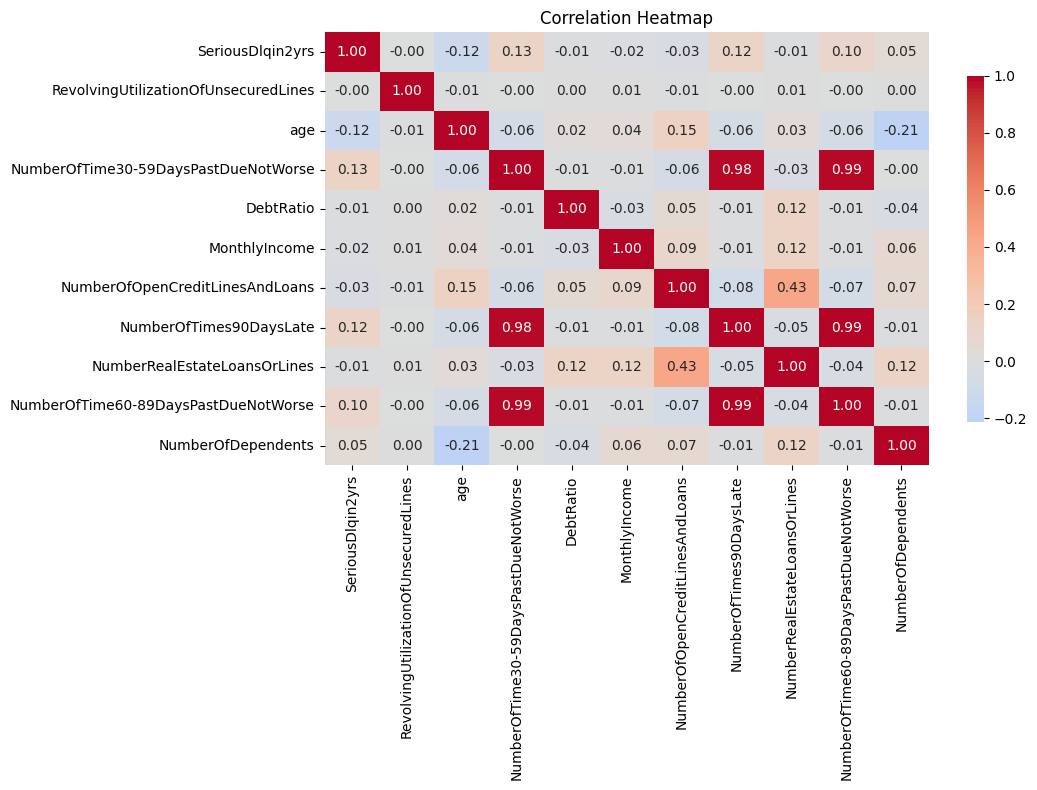


Correlation with default (SeriousDlqin2yrs):
SeriousDlqin2yrs                        1.000
NumberOfTime30-59DaysPastDueNotWorse    0.126
NumberOfTimes90DaysLate                 0.117
NumberOfTime60-89DaysPastDueNotWorse    0.102
NumberOfDependents                      0.046
RevolvingUtilizationOfUnsecuredLines   -0.002
NumberRealEstateLoansOrLines           -0.007
DebtRatio                              -0.008
MonthlyIncome                          -0.020
NumberOfOpenCreditLinesAndLoans        -0.030
age                                    -0.115
Name: SeriousDlqin2yrs, dtype: float64


In [10]:
# Correlation of all features with the target
plt.figure(figsize=(11, 8))

# Drop the helper columns we made earlier so they don't clutter the matrix
corr_df = df.drop(columns=["age_group", "late_bucket"], errors="ignore")

corr = corr_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Just the correlations WITH the target, sorted
print("\nCorrelation with default (SeriousDlqin2yrs):")
print(corr["SeriousDlqin2yrs"].sort_values(ascending=False).round(3))

In [11]:
# Handle missing values
df_clean = df.drop(columns=["age_group", "late_bucket"], errors="ignore").copy()

df_clean["MonthlyIncome"] = df_clean["MonthlyIncome"].fillna(df_clean["MonthlyIncome"].median())
df_clean["NumberOfDependents"] = df_clean["NumberOfDependents"].fillna(0)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

# Separate features (X) from the target (y)
X = df_clean.drop(columns=["SeriousDlqin2yrs"])
y = df_clean["SeriousDlqin2yrs"]

# Split into train/test — stratify=y keeps the same default rate in both halves
# (important because the data is imbalanced)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nDefault rate in train:", round(y_train.mean() * 100, 2), "%")
print("Default rate in test: ", round(y_test.mean() * 100, 2), "%")

Training set: (120000, 10)
Test set: (30000, 10)

Default rate in train: 6.68 %
Default rate in test:  6.68 %


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# class_weight="balanced" tells the model to take the rare default class seriously
# (otherwise it would just predict "no default" for everyone and call it 93% accurate)
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train, y_train)

# Predict
y_pred_lr = logreg.predict(X_test)
y_proba_lr = logreg.predict_proba(X_test)[:, 1]  # probability of default

# Evaluate on the RIGHT metrics for imbalanced data
print("=== Logistic Regression ===")
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred_lr, target_names=["No Default", "Default"]))

=== Logistic Regression ===
ROC-AUC: 0.8006

Classification report:
              precision    recall  f1-score   support

  No Default       0.97      0.78      0.87     27995
     Default       0.18      0.67      0.28      2005

    accuracy                           0.77     30000
   macro avg       0.58      0.73      0.58     30000
weighted avg       0.92      0.77      0.83     30000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Scale features, then fit logistic regression — scaling fixes the convergence warning
# and usually improves the model
logreg_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
logreg_scaled.fit(X_train, y_train)

y_proba_lr = logreg_scaled.predict_proba(X_test)[:, 1]
y_pred_lr = logreg_scaled.predict(X_test)

print("=== Logistic Regression (scaled) ===")
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 4))
print(classification_report(y_test, y_pred_lr, target_names=["No Default", "Default"]))

=== Logistic Regression (scaled) ===
ROC-AUC: 0.8021
              precision    recall  f1-score   support

  No Default       0.97      0.78      0.87     27995
     Default       0.18      0.67      0.29      2005

    accuracy                           0.78     30000
   macro avg       0.58      0.73      0.58     30000
weighted avg       0.92      0.78      0.83     30000



In [15]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest — handles non-linear relationships and multicollinearity well
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1   # use all CPU cores so it trains faster
)
rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))
print(classification_report(y_test, y_pred_rf, target_names=["No Default", "Default"]))

=== Random Forest ===
ROC-AUC: 0.8427
              precision    recall  f1-score   support

  No Default       0.94      0.99      0.97     27995
     Default       0.57      0.16      0.25      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.57      0.61     30000
weighted avg       0.92      0.94      0.92     30000



In [16]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "ROC-AUC": round(roc_auc_score(y_true, y_proba), 4),
        "Precision (Default)": round(precision_score(y_true, y_pred), 4),
        "Recall (Default)": round(recall_score(y_true, y_pred), 4),
        "F1 (Default)": round(f1_score(y_true, y_pred), 4),
    }

results = pd.DataFrame([
    get_metrics("Logistic Regression", y_test, logreg_scaled.predict(X_test), logreg_scaled.predict_proba(X_test)[:,1]),
    get_metrics("Random Forest", y_test, y_pred_rf, y_proba_rf),
])

results

,Model,ROC-AUC,Precision (Default),Recall (Default),F1 (Default)
0,Logistic Regression,0.8021,0.1817,0.6698,0.2858
1,Random Forest,0.8427,0.5694,0.1576,0.2469


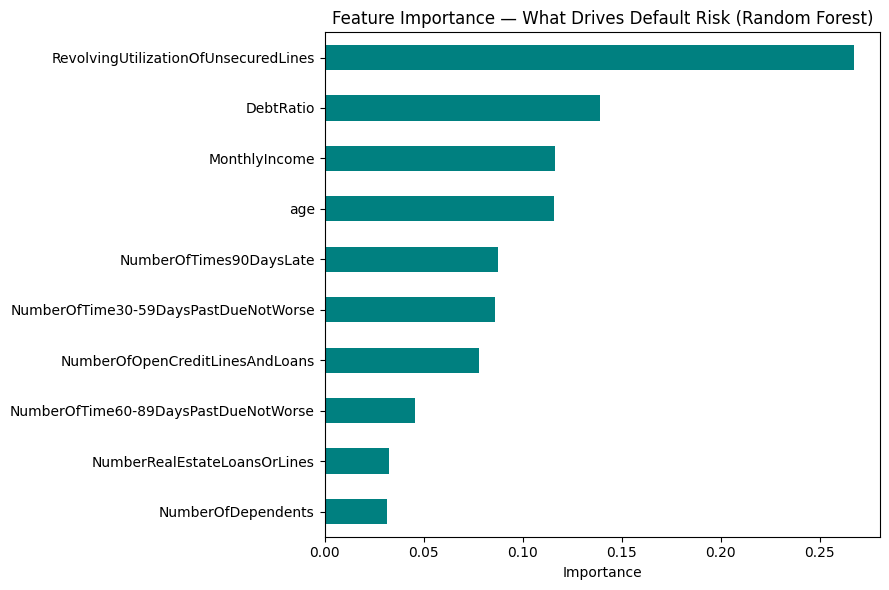

RevolvingUtilizationOfUnsecuredLines    0.2671
DebtRatio                               0.1390
MonthlyIncome                           0.1165
age                                     0.1158
NumberOfTimes90DaysLate                 0.0877
NumberOfTime30-59DaysPastDueNotWorse    0.0860
NumberOfOpenCreditLinesAndLoans         0.0781
NumberOfTime60-89DaysPastDueNotWorse    0.0458
NumberRealEstateLoansOrLines            0.0323
NumberOfDependents                      0.0317
dtype: float64


In [17]:
import matplotlib.pyplot as plt

# Get feature importance from the Random Forest (the better model)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
importances.plot(kind="barh", color="teal")
plt.title("Feature Importance — What Drives Default Risk (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()  # most important at top
plt.tight_layout()
plt.show()

print(importances.round(4))

The factors that increase the probability of default are identified as high credit utilization ratio, high debt to income ratio, low income, young age, and late payment history. The Random Forest ranking gives an accuracy of 0.84 based on the ROC-AUC score. On behalf of the bank, the ranking algorithm can be used to select those application that need to be reviewed — but the trade-off between precision and recall needs to be adjusted according to the costs of the business: higher recall leads to more defaults, but also more good clients will be rejected.